# Network Performance Monitoring Dashboard


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-muted')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Data Loading & Initial Setup

In [ ]:
file_path = 'Midterm_53_group.csv'
df = pd.read_csv(file_path)

print(f"Total Packets: {len(df):,}")
df.head()

Total Packets: 394,136


,Time,Source,No.,Destination,Protocol,Length,Info
0,0.000000,192.167.8.166,1,192.167.255.255,NBNS,92,Name query NB WPAD<00>
1,0.784682,192.167.8.166,2,192.167.255.255,NBNS,92,Name query NB WPAD<00>
2,1.169060,VMware_8a:5c:e6,3,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
3,2.167949,VMware_8a:5c:e6,4,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1
4,3.170095,VMware_8a:5c:e6,5,Broadcast,ARP,60,Who has 192.167.7.175? Tell 192.167.0.1


## 2. Bandwidth Analysis (Throughput over Time)

เราจะดูว่าในแต่ละช่วงเวลามีปริมาณข้อมูล (Bytes) วิ่งมากน้อยแค่ไหน เพื่อหาจุดที่มีการใช้งานหนาแน่น (Peak Usage)

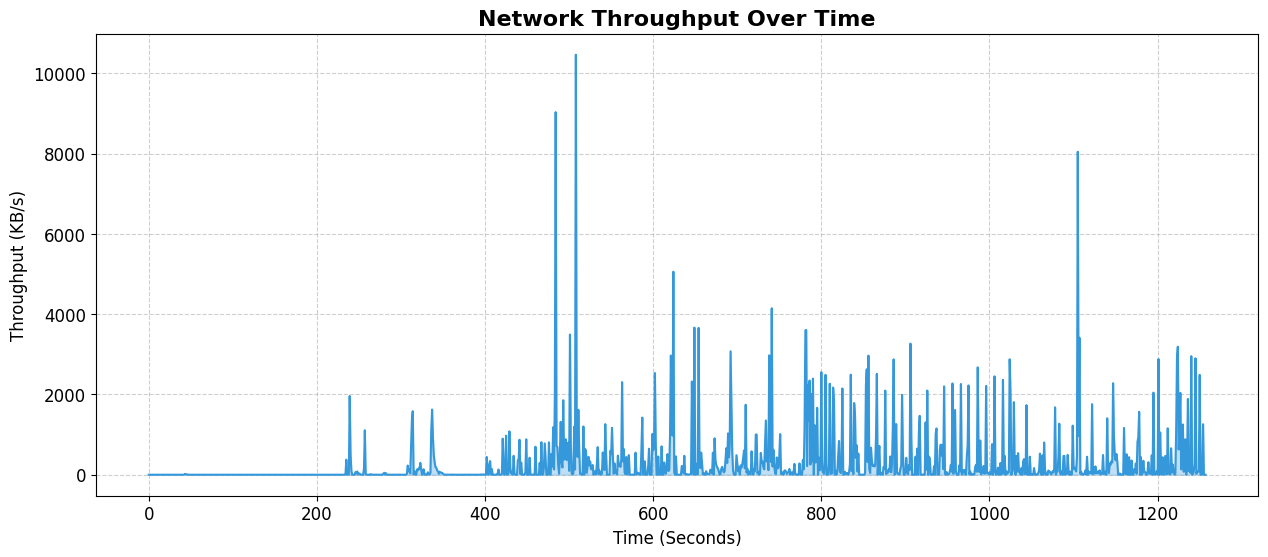

In [5]:
df['Time_Round'] = df['Time'].round()

throughput = df.groupby('Time_Round')['Length'].sum().reset_index()
throughput['Throughput_KBps'] = throughput['Length'] / 1024 # KB

plt.figure(figsize=(15, 6))
plt.plot(throughput['Time_Round'], throughput['Throughput_KBps'], color='#3498db', linewidth=1.5)
plt.fill_between(throughput['Time_Round'], throughput['Throughput_KBps'], alpha=0.3, color='#3498db')
plt.title('Network Throughput Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Time (Seconds)', fontsize=12)
plt.ylabel('Throughput (KB/s)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Traffic Composition (Protocol Analysis)

วิเคราะห์ว่าระบบใช้แบนด์วิดท์ไปกับโปรโตคอลประเภทไหนมากที่สุด เพื่อดูความผิดปกติหรือการใช้งานที่เกินความจำเป็น

C:\Users\ananz\AppData\Local\Temp\ipykernel_48756\1091936883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proto_usage.index, y=proto_usage['Volume_MB'], ax=ax1, palette='magma')


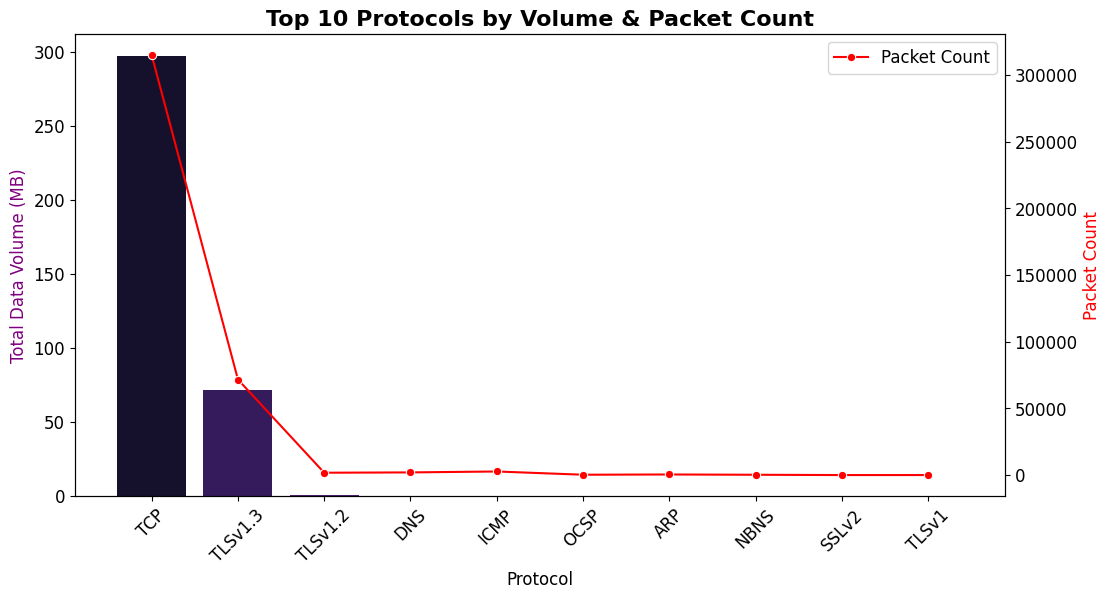

In [6]:
proto_usage = df.groupby('Protocol')['Length'].agg(['sum', 'count']).sort_values(by='sum', ascending=False).head(10)
proto_usage['Volume_MB'] = proto_usage['sum'] / (1024 * 1024)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(x=proto_usage.index, y=proto_usage['Volume_MB'], ax=ax1, palette='magma')
ax1.set_ylabel('Total Data Volume (MB)', color='purple', fontsize=12)
ax1.set_title('Top 10 Protocols by Volume & Packet Count', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
sns.lineplot(x=proto_usage.index, y=proto_usage['count'], ax=ax2, color='red', marker='o', label='Packet Count')
ax2.set_ylabel('Packet Count', color='red', fontsize=12)
ax2.legend(loc='upper right')

plt.show()

## 4. Top Talkers (Entities Analysis)

ค้นหาว่า IP หรือ Host ไหนที่เป็นคนส่ง/รับข้อมูลเยอะที่สุด (Bandwidth Hogs)

C:\Users\ananz\AppData\Local\Temp\ipykernel_48756\267429825.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_senders, x='Volume_MB', y='Source', palette='viridis')


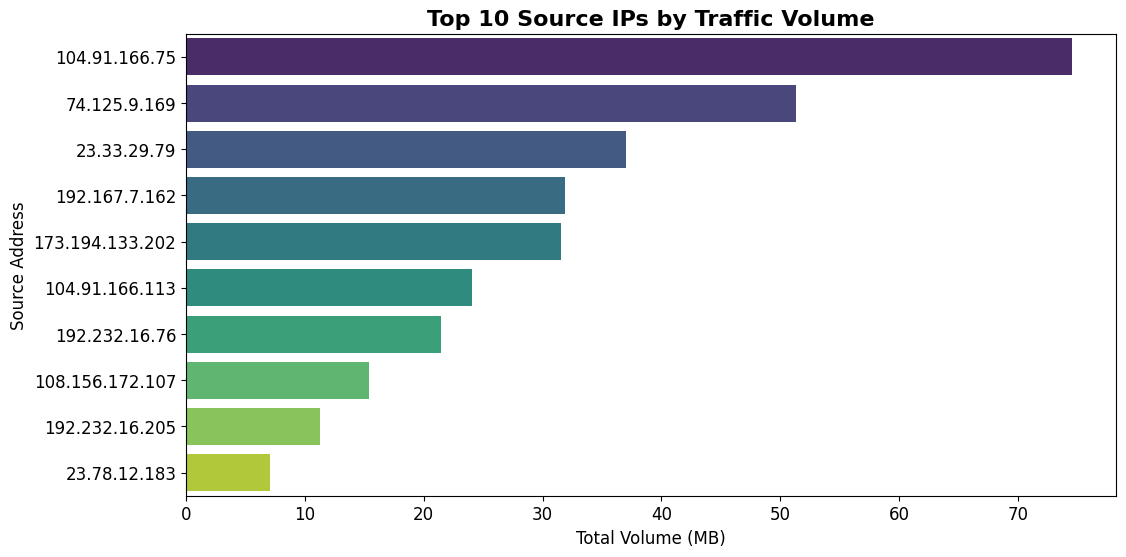

In [7]:
top_senders = df.groupby('Source')['Length'].sum().sort_values(ascending=False).head(10).reset_index()
top_senders['Volume_MB'] = top_senders['Length'] / (1024 * 1024)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_senders, x='Volume_MB', y='Source', palette='viridis')
plt.title('Top 10 Source IPs by Traffic Volume', fontsize=16, fontweight='bold')
plt.xlabel('Total Volume (MB)', fontsize=12)
plt.ylabel('Source Address', fontsize=12)
plt.show()

## 5. Summary & Health Check

สรุปสถานะของเครือข่ายเบื้องต้น

In [8]:
total_duration = df['Time'].max() - df['Time'].min()
total_data = df['Length'].sum() / (1024 * 1024)
avg_throughput = total_data / total_duration if total_duration > 0 else 0

print("=== Network Performance Summary ===")
print(f"Observation Period: {total_duration:.2f} seconds")
print(f"Total Data Transferred: {total_data:.2f} MB")
print(f"Average Throughput: {avg_throughput:.2f} MB/s")
print(f"Highest Single Packet Size: {df['Length'].max()} bytes")
print(f"Most Active Protocol: {df['Protocol'].mode()[0]}")

=== Network Performance Summary ===
Observation Period: 1256.92 seconds
Total Data Transferred: 370.46 MB
Average Throughput: 0.29 MB/s
Highest Single Packet Size: 49745 bytes
Most Active Protocol: TCP
